In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import episcanpy as epi
import anndata as ad
import scipy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, matthews_corrcoef, confusion_matrix
from sklearn.linear_model import LogisticRegression
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

np.random.seed(0)
torch.manual_seed(0)

In [ ]:
def tfidf_seurat(adata: ad.AnnData, scale_factor=10000) -> None:
    r"""
    TF-IDF normalization.
    This function normalizes the ATAC peak counts.

    Parameters
    ----------
    adata : ad.AnnData
        Input AnnData object containing raw ATAC counts in `.X`.

    Returns
    -------
    X_tfidf : scipy.sparse matrix or np.ndarray
        TF-IDF normalized matrix.
    """
    X = adata.X
    
    # 1. Term Frequency (TF)
    if scipy.sparse.issparse(X):
        row_sums = X.sum(axis=1).A1
        row_sums[row_sums == 0] = 1
        tf = X.multiply(scale_factor / row_sums.reshape(-1, 1))
    else:
        row_sums = X.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        tf = X * (scale_factor / row_sums)
    
    # 2. Inverse Document Frequency (IDF)
    n_cells = X.shape[0]
    
    if scipy.sparse.issparse(X):
        cells_per_feature = X.getnnz(axis=0)
        idf = n_cells / (cells_per_feature + 1)
    else:
        cells_per_feature = np.count_nonzero(X, axis=0)
        idf = n_cells / (cells_per_feature + 1)
    
    # 3. TF-IDF Calculation with log1p transformation
    if scipy.sparse.issparse(tf):
        X_tfidf = tf.multiply(idf)
        X_tfidf.data = np.log1p(X_tfidf.data)  # log(1+x)
        if hasattr(X_tfidf, 'tocsr'):
            X_tfidf = X_tfidf.tocsr()
    else:
        X_tfidf = tf * idf
        X_tfidf = np.log1p(X_tfidf)
    return X_tfidf

In [ ]:
class ScClassifier:
    def __init__(self, models_config=None):
        self.models = {}
        self.scalers = {}
        self.label_encoder = LabelEncoder()
        
        # Default model configuration
        if models_config is None:
            self.models_config = {
                'LogisticRegression': LogisticRegression(max_iter=1000, random_state=0),
            }
        else:
            self.models_config = models_config
    
    def prepare_data(self, scRNA, scATAC=None, scATAC_preds=None, data_type='scRNA_only'):
        """
        Prepare different combinations of omics data for training.
        
        Args:
            scRNA: scRNA-seq data (AnnData)
            scATAC: scATAC-seq data (AnnData)
            scATAC_preds: Predicted scATAC data (AnnData)
            data_type: Combination strategy
                'scRNA_only': Only scRNA
                'scRNA_scATAC': scRNA + Real scATAC
                'scRNA_scATAC_preds': scRNA + Predicted scATAC
                
        Returns:
            X: Feature matrix
            y: Encoded labels
            feature_names: List of feature names
        """
        if data_type == 'scRNA_only':
            # Extract RNA profile
            X = scRNA.X.toarray() if hasattr(scRNA.X, 'toarray') else scRNA.X
            feature_names = scRNA.var_names.tolist()
            
        elif data_type == 'scRNA_scATAC':
            # Extract RNA profile and ATAC accessibility
            X_rna = scRNA.X.toarray() if hasattr(scRNA.X, 'toarray') else scRNA.X
            X_atac = scATAC.X.toarray() if hasattr(scATAC.X, 'toarray') else scATAC.X
            
            # # Horizontally stack RNA and ATAC modalities
            X = np.hstack([X_rna, X_atac])
            feature_names = scRNA.var_names.tolist() + scATAC.var_names.tolist()
            
        elif data_type == 'scRNA_scATAC_preds':
            # Extract RNA profile and predicted accessibility
            X_rna = scRNA.X.toarray() if hasattr(scRNA.X, 'toarray') else scRNA.X
            X_atac_preds = scATAC_preds.X.toarray() if hasattr(scATAC_preds.X, 'toarray') else scATAC_preds.X
            
            # # Horizontally stack RNA and ATAC modalities
            X = np.hstack([X_rna, X_atac_preds])
            feature_names = scRNA.var_names.tolist() + scATAC_preds.var_names.tolist()
        else:
            raise ValueError(f"Unknown data_type: {data_type}")
        
        # Extract ground truth labels
        label_col = 'cell_type'
        y = scRNA.obs[label_col].values
        
        # Encode labels to 0/1 integers (e.g., 'Normal' -> 0, 'Tumor' -> 1)
        y = self.label_encoder.fit_transform(y)
        
        return X, y
    
    def train_test_split_data(self, X, y, test_size=0.1):
        """Split data into training and testing sets with stratification."""
        return train_test_split(X, y, test_size=test_size, stratify=y, random_state=0)
    
    def train_ml_models(self, X_train, X_test, y_train, y_test, model_name):
        """Train a specified machine learning model and generate predictions."""
        # Standardize features by removing the mean and scaling to unit variance
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Clone the model to ensure independent training states across different data_types
        model = self.models_config[model_name]
        model.fit(X_train_scaled, y_train)
        
        # Generate predictions and probabilities
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
        
        # Store fitted artifacts
        self.models[model_name] = model
        self.scalers[model_name] = scaler
        
        return y_pred, y_prob
    
    def evaluate_model(self, y_true, y_pred, y_prob):
        """Calculate classification metrics."""
        metrics = {}
        
        # AUC-ROC
        if y_prob is not None:
            metrics['AUROC'] = roc_auc_score(y_true, y_prob)
        else:
            metrics['AUROC'] = None
        
        # AUPR
        if y_prob is not None:
            metrics['AUPR'] = average_precision_score(y_true, y_prob)
        else:
            metrics['AUPR'] = None
        
        # F1 Score
        metrics['F1'] = f1_score(y_true, y_pred)
        
        # MCC
        metrics['MCC'] = matthews_corrcoef(y_true, y_pred)
        
        # Calculate accuracy from confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        accuracy = np.trace(cm) / np.sum(cm)
        metrics['Accuracy'] = accuracy
        
        return metrics


def run_comparison_experiment(n, scRNA, scATAC=None, scATAC_preds=None):
    """
    Run ablation experiments across different omics combinations.
    """
    data_types = ['scRNA_only', 'scRNA_scATAC', 'scRNA_scATAC_preds']
    results = {}
    
    # Initialize the classifier wrapper
    ml_classifier = ScClassifier()
    
    for data_type in data_types:
        print(f"\n{'='*50}")
        print(f"data type: {data_type}")
        print(f"{'='*50}")
        
        try:
            # 1. Data Preparation
            X, y= ml_classifier.prepare_data(
                scRNA, scATAC, scATAC_preds, data_type
            )
            print(f"data shape: {X.shape}")
            print(f"bincount: {np.bincount(y)}")
            
            # 2. Train/Test Split
            X_train, X_test, y_train, y_test = ml_classifier.train_test_split_data(X, y)
            results[data_type] = {}
            
            # 3. Model Training and Evaluation
            for model_name in ml_classifier.models_config.keys():
                print(f"\ntraining {model_name}...")
                
                try:
                    y_pred, y_prob = ml_classifier.train_ml_models(
                        X_train, X_test, y_train, y_test, model_name
                    )
                    
                    metrics = ml_classifier.evaluate_model(y_test, y_pred, y_prob)
                    results[data_type][model_name] = metrics
                    
                    print(f"hvg {n} result: AUROC={metrics['AUROC']:.3f}, "
                          f"AUPR={metrics['AUPR']:.3f}, "
                          f"F1={metrics['F1']:.3f}, "
                          f"MCC={metrics['MCC']:.3f}")
                except Exception as e:
                    print(f"training {model_name} error: {e}")
                    results[data_type][model_name] = None
            
        except Exception as e:
            print(f"deal with data {data_type} error: {e}")
            results[data_type] = None
    
    return results


def main(n, scRNA, scATAC, scATAC_preds):
    """Main entry for the experiment."""
    results = run_comparison_experiment(n, scRNA, scATAC, scATAC_preds)
    return results

In [ ]:
def aggregate_and_plot_results(all_results, prefix):
    """
    Aggregate all Highly Variable Genes (HVG) results and plot the comparison metrics.
    """
    # Prepare data list for plotting
    plot_data = []
    # Iterate through the nested dictionary to extract evaluation metrics
    for hvg_n, results in all_results.items():
        if results is not None:
            for data_type, metrics in results.items():
                if metrics is not None:
                    plot_data.append({
                        'HVG_Number': hvg_n,
                        'Data_Type': data_type,
                        'AUROC': metrics['LogisticRegression']['AUROC'],
                        'AUPR': metrics['LogisticRegression']['AUPR'],
                        'F1': metrics['LogisticRegression']['F1'],
                        'MCC': metrics['LogisticRegression']['MCC']
                    })
    
    # Create a DataFrame from the aggregated data
    summary_df = pd.DataFrame(plot_data)
    
    # Save the summarized results to a CSV file
    summary_df.to_csv(f'{prefix}/statistic/tumor_classification_results_summary.csv', index=False)
    print(f"\nsave result: statistic/tumor_classification_results_summary.csv")
    
    # Print the summarized results to the console
    print("\n" + "="*80)
    print("result conclusion:")
    print("="*80)
    print(summary_df.to_string())
    
    # Visualize the comparison
    plot_comparison(summary_df)
    
    return summary_df


def plot_comparison(summary_df):
    """
    Visualize the comparison results using a 2x2 grid of line plots.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Set visualization style and palette
    sns.set_style("whitegrid")
    sns.set_palette("tab10")
    plt.figure(figsize=(16, 10))
    
    # Define the metrics to plot along with their specific y-axis limits
    metrics_info = {
        'AUROC': {'title': 'AUROC', 'ylim': [0.99, 1.0]},
        'AUPR': {'title': 'AUPRC', 'ylim': [0.99, 1.0]},
        'F1': {'title': 'F1', 'ylim': [0.97, 0.99]},
        'MCC': {'title': 'MCC', 'ylim': [0.93, 0.97]}
    }
    
    # Extract and sort the unique HVG numbers and data types
    hvg_numbers = sorted(summary_df['HVG_Number'].unique())
    data_types = summary_df['Data_Type'].unique()
    
    colors = ['#c03d3e', '#3274a1', '#3a923a']
    # Iterate over the metrics to create subplots
    for idx, (metric, info) in enumerate(metrics_info.items(), 1):
        plt.subplot(2, 2, idx)
        
        for i, data_type in enumerate(data_types):
            data_subset = summary_df[summary_df['Data_Type'] == data_type].copy()
            data_subset = data_subset.sort_values('HVG_Number')
            plt.plot(data_subset['HVG_Number'], data_subset[metric], 
                    marker='o', linewidth=2, markersize=8, label=data_type, color=colors[i])
            for _, row in data_subset.iterrows():
                plt.text(row['HVG_Number'], row[metric] + 0.0002, f'{row[metric]:.4f}', 
                        ha='center', va='bottom', fontsize=10)
        plt.title(f'{info["title"]}', fontsize=14)
        plt.xlabel('Number of HVGs', fontsize=12)
        plt.xticks(hvg_numbers, fontsize=10)
        if info['ylim']:
            plt.ylim(info['ylim'][0], info['ylim'][1])
        plt.grid(True, alpha=0.3)
        if idx == 1:
            plt.legend(title='Data Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    
    plt.savefig('figures/tumor_classification_hvg_comparison.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
print("loading data...")
prefix = "/path/data"
scRNA = sc.read(f'{prefix}/tumor/rna_tumor.h5ad')
scATAC = sc.read(f'{prefix}/tumor/tumor_atac.h5ad')
sc.pp.filter_genes(scRNA, min_cells=3000)
sc.pp.normalize_total(scRNA, target_sum=1e4)
sc.pp.log1p(scRNA)
scRNA.obs['cell_type'] = scRNA.obs['cell_type'].cat.add_categories(['Normal'])
scRNA.obs.loc[scRNA.obs['cell_type'] != 'Tumor', 'cell_type'] = 'Normal'
all_results = {}
for i in [1000, 2000, 3000, 4000, 5000]:
    sc.pp.highly_variable_genes(scRNA, n_top_genes=i)
    scRNA_hvg = scRNA[:, scRNA.var['highly_variable']].copy()
    print("scRNA_hvg shape:", scRNA_hvg.shape)
    scATAC_hvg = scATAC.copy()
    epi.pp.select_var_feature(scATAC_hvg, nb_features=i, show=False)
    print("scATAC_hvg shape:", scATAC_hvg.shape)
    scATAC_preds = sc.read(f'{prefix}/prediction/tumor/allchr_tumor_allcell_preds_HVG_{i}.h5ad')
    print("scATAC_preds shape:", scATAC_hvg.shape)
    results = main(i, scRNA_hvg, scATAC_hvg, scATAC_preds)
    all_results[i] = results   


loading data...
scRNA_hvg shape: (269741, 2158)
scATAC_hvg shape: (269741, 3001)
scATAC_preds shape: (269741, 3001)

data type: scRNA_only
data shape: (269741, 2158)
bincount: [115403 154338]

training LogisticRegression...
hvg 3000 result: AUROC=0.993, AUPR=0.994, F1=0.980, MCC=0.953

data type: scRNA_scATAC
data shape: (269741, 5159)
bincount: [115403 154338]

training LogisticRegression...
hvg 3000 result: AUROC=0.994, AUPR=0.995, F1=0.981, MCC=0.956

data type: scRNA_scATAC_preds
data shape: (269741, 5159)
bincount: [115403 154338]

training LogisticRegression...
hvg 3000 result: AUROC=0.996, AUPR=0.997, F1=0.984, MCC=0.961
scRNA_hvg shape: (269741, 1000)
scATAC_hvg shape: (269741, 1001)
scATAC_preds shape: (269741, 1001)

data type: scRNA_only
data shape: (269741, 1000)
bincount: [115403 154338]

training LogisticRegression...
hvg 1000 result: AUROC=0.991, AUPR=0.992, F1=0.974, MCC=0.939

data type: scRNA_scATAC
data shape: (269741, 2001)
bincount: [115403 154338]

training Logist


save result: statistic/tumor_classification_results_summary.csv

result conclusion:
    HVG_Number           Data_Type     AUROC      AUPR        F1       MCC
0         3000          scRNA_only  0.993358  0.994176  0.980071  0.953437
1         3000        scRNA_scATAC  0.994467  0.994670  0.981009  0.955634
2         3000  scRNA_scATAC_preds  0.996394  0.997141  0.983517  0.961454
3         1000          scRNA_only  0.991410  0.992499  0.973826  0.938817
4         1000        scRNA_scATAC  0.993445  0.993756  0.978580  0.949954
5         1000  scRNA_scATAC_preds  0.994598  0.995478  0.978719  0.950249
6         2000          scRNA_only  0.993305  0.994116  0.980043  0.953358
7         2000        scRNA_scATAC  0.994457  0.994698  0.981341  0.956384
8         2000  scRNA_scATAC_preds  0.995801  0.996549  0.982554  0.959177
9         4000          scRNA_only  0.993358  0.994176  0.980071  0.953437
10        4000        scRNA_scATAC  0.994257  0.994549  0.978865  0.950641
11        4000 

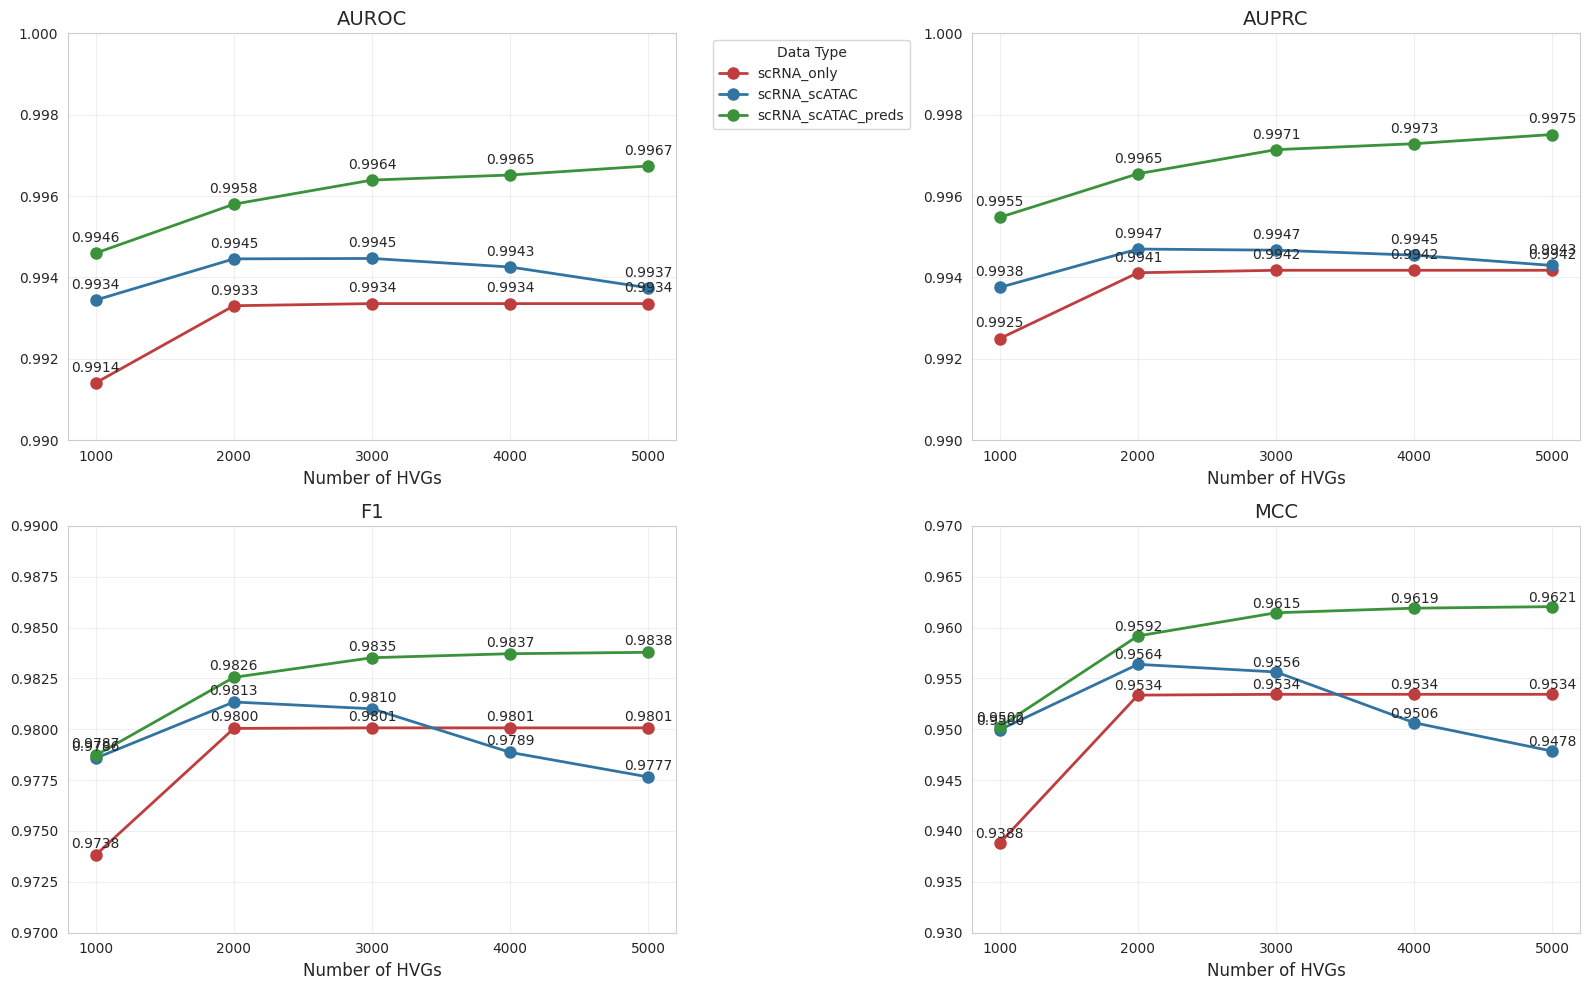

In [ ]:
summary_df = aggregate_and_plot_results(all_results, prefix)